# Azul fleet exploratory analysis

This notebook explores the Azul fleet sample with three goals:

1. **Group similar aircraft** based on operational behavior, especially **take-off weight**, **trip time**, **distance**, and **fuel burn**
2. **Create scatter plots with trend lines** to inspect pairwise relationships
3. **Start a correlation analysis** to identify variables that may be useful for later modeling

The project context emphasizes fuel efficiency as a function of **aircraft type, flight distance, and take-off weight**, so the notebook is organized around those dimensions.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster

plt.rcParams["figure.figsize"] = (10, 6)
pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

DATA_PATH = "Azul_DataSample.xlsx"
RANDOM_STATE = 42

df = pd.read_excel(DATA_PATH)
df = df.rename(columns={
    "TripFuelBurnTotal [KG]": "fuel_kg",
    "TakeOffWeight  [KG]": "tow_kg",
    "TripTimeSec": "trip_time_sec",
    "GroundDistance [NM]": "distance_nm"
})
df["STDUTC"] = pd.to_datetime(df["STDUTC"])
df["trip_time_min"] = df["trip_time_sec"] / 60
df["route"] = df["DepartureStation"] + "-" + df["ArrivalStation"]

df.head()

,FlightNumber,STDUTC,DepartureStation,ArrivalStation,Equipment,fuel_kg,tow_kg,trip_time_sec,distance_nm,trip_time_min,route
0,4992,2024-05-05 18:20:00,CXJ,VCP,A320,2671,65264,4380,463.10,73.00,CXJ-VCP
1,9002,2024-06-04 16:55:00,VCP,QNS,E1,3143,47891,5340,487.20,89.00,VCP-QNS
2,4942,2024-07-04 09:20:00,VCP,SSA,A320,4389,71041,7020,815.50,117.00,VCP-SSA
3,4942,2024-07-25 09:20:00,VCP,SSA,A320,4546,68618,7620,862.20,127.00,VCP-SSA
4,2601,2024-10-07 06:20:00,MAO,REC,A321,9624,87335,12960,"1,561.10",216.00,MAO-REC


## 1. Basic exploratory analysis

Before grouping aircraft, it is worth checking data quality and understanding the operational coverage of the sample.


In [6]:
summary = pd.DataFrame({
    "metric": [
        "rows",
        "columns",
        "date_min",
        "date_max",
        "missing_values",
        "duplicate_rows",
        "unique_aircraft_types",
        "unique_routes",
        "unique_airports"
    ],
    "value": [
        len(df),
        df.shape[1],
        df["STDUTC"].min(),
        df["STDUTC"].max(),
        int(df.isna().sum().sum()),
        int(df.duplicated().sum()),
        df["Equipment"].nunique(),
        df["route"].nunique(),
        pd.unique(df[["DepartureStation", "ArrivalStation"]].values.ravel("K")).size
    ]
})
summary

,metric,value
0,rows,288337
1,columns,11
2,date_min,2024-01-01 00:05:00
3,date_max,2025-11-15 06:20:00
4,missing_values,0
5,duplicate_rows,0
6,unique_aircraft_types,5
7,unique_routes,419
8,unique_airports,113


In [7]:
numeric_cols = ["fuel_kg", "tow_kg", "trip_time_min", "distance_nm"]
df[numeric_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
fuel_kg,"288,337.00","2,851.71","2,164.01","-37,110.00","1,011.00","2,158.00","4,378.00","16,413.00"
tow_kg,"288,337.00","48,665.17","19,463.35","14,838.00","22,372.00","52,276.00","65,959.00","88,992.00"
trip_time_min,"288,337.00",91.51,49.04,-87.00,54.00,74.00,128.00,485.00
distance_nm,"288,337.00",556.13,390.70,16.00,258.60,385.10,882.00,"3,610.70"


In [8]:
equipment_counts = (
    df["Equipment"]
    .value_counts()
    .rename_axis("equipment")
    .reset_index(name="flights")
)
equipment_counts

,equipment,flights
0,A320,100893
1,ATR,78520
2,E2,50314
3,E1,44816
4,A321,13794


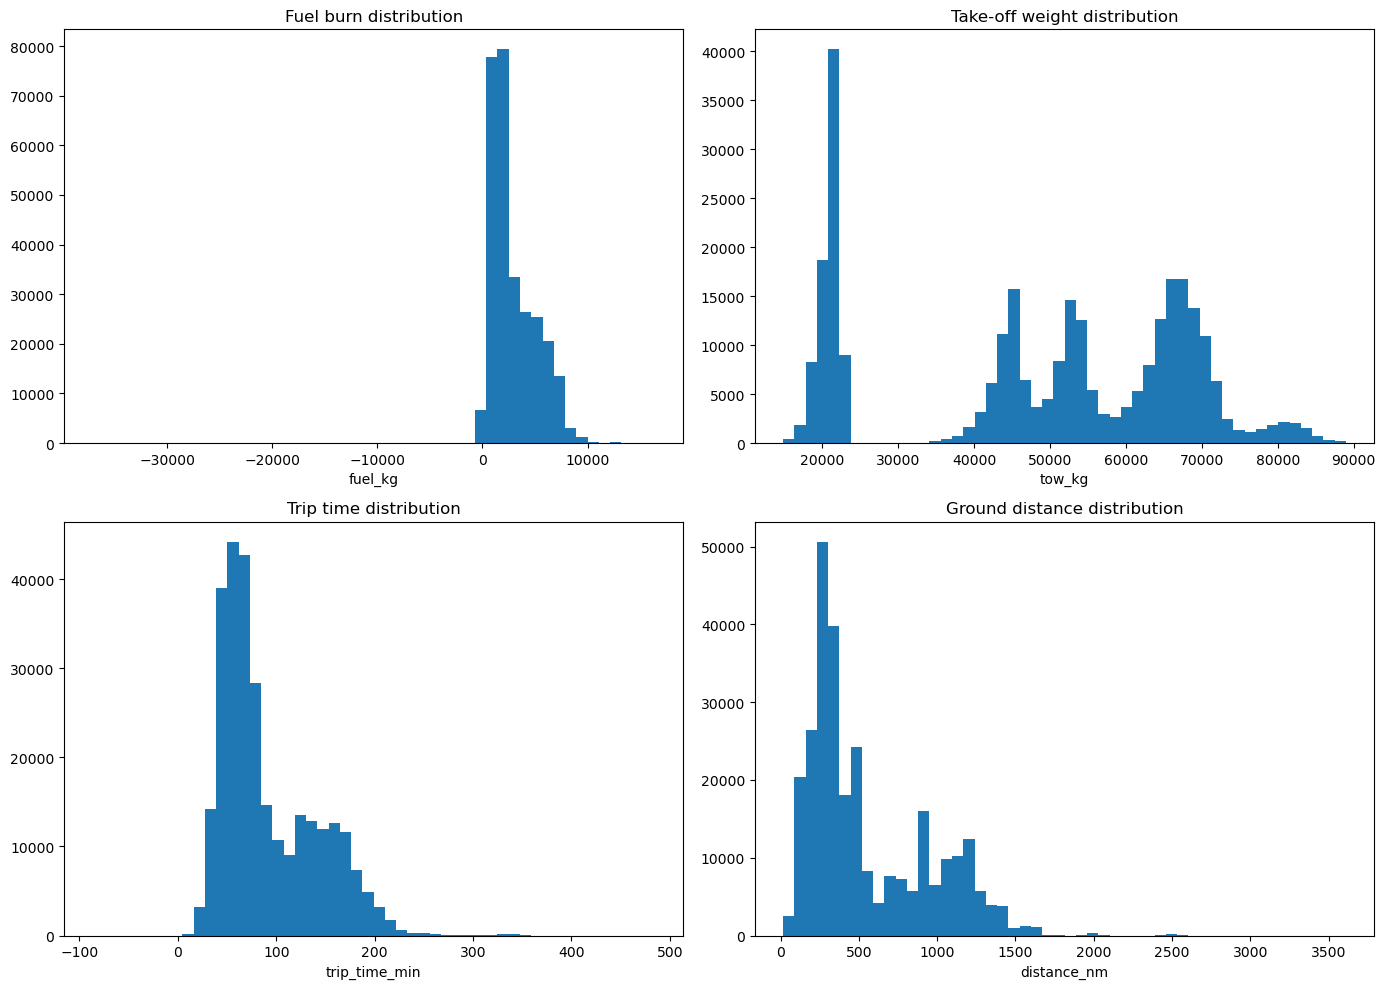

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].hist(df["fuel_kg"], bins=50)
axes[0, 0].set_title("Fuel burn distribution")
axes[0, 0].set_xlabel("fuel_kg")

axes[0, 1].hist(df["tow_kg"], bins=50)
axes[0, 1].set_title("Take-off weight distribution")
axes[0, 1].set_xlabel("tow_kg")

axes[1, 0].hist(df["trip_time_min"], bins=50)
axes[1, 0].set_title("Trip time distribution")
axes[1, 0].set_xlabel("trip_time_min")

axes[1, 1].hist(df["distance_nm"], bins=50)
axes[1, 1].set_title("Ground distance distribution")
axes[1, 1].set_xlabel("distance_nm")

plt.tight_layout()
plt.show()

In [10]:
equipment_profile = (
    df.groupby("Equipment")
      .agg(
          flights=("FlightNumber", "count"),
          unique_routes=("route", "nunique"),
          tow_mean=("tow_kg", "mean"),
          tow_median=("tow_kg", "median"),
          trip_time_mean_min=("trip_time_min", "mean"),
          trip_time_median_min=("trip_time_min", "median"),
          distance_mean_nm=("distance_nm", "mean"),
          distance_median_nm=("distance_nm", "median"),
          fuel_mean_kg=("fuel_kg", "mean"),
          fuel_median_kg=("fuel_kg", "median")
      )
      .sort_values("distance_mean_nm")
)
equipment_profile

,flights,unique_routes,tow_mean,tow_median,trip_time_mean_min,trip_time_median_min,distance_mean_nm,distance_median_nm,fuel_mean_kg,fuel_median_kg
Equipment,,,,,,,,,,
ATR,78520,220,"20,881.07","21,225.00",62.80,62.00,231.28,231.00,671.55,660.00
E1,44816,269,"43,961.83","44,428.50",60.66,53.00,354.00,295.60,"2,252.26","1,994.00"
E2,50314,260,"52,455.81","52,743.00",78.58,64.00,491.27,382.80,"2,345.78","1,977.00"
A320,100893,294,"66,298.47","66,644.00",123.86,128.00,846.76,889.20,"4,495.91","4,529.00"
A321,13794,96,"79,301.27","80,116.50",165.62,167.00,"1,172.84","1,170.40","7,028.72","7,116.50"


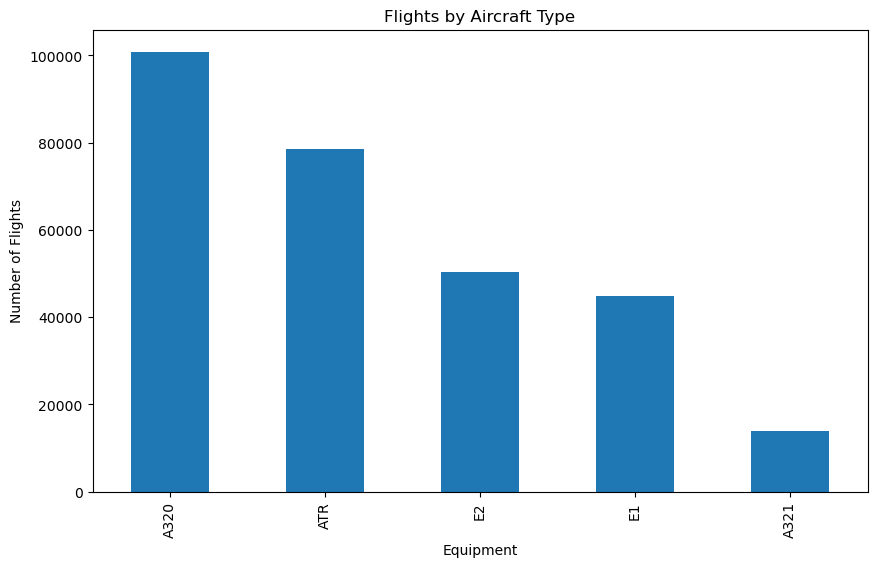

In [3]:
fleet_counts = df["Equipment"].value_counts()

fleet_counts.plot(kind="bar")
plt.title("Flights by Aircraft Type")
plt.ylabel("Number of Flights")
plt.show()

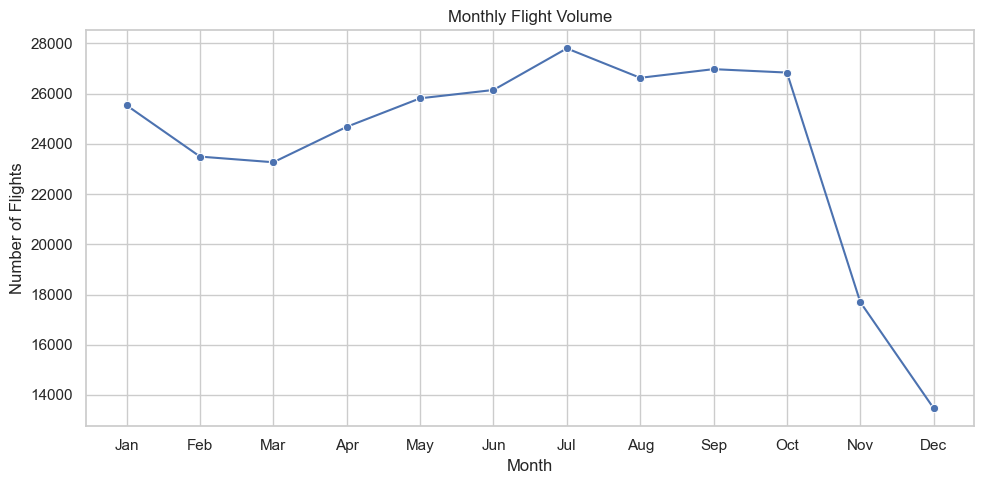

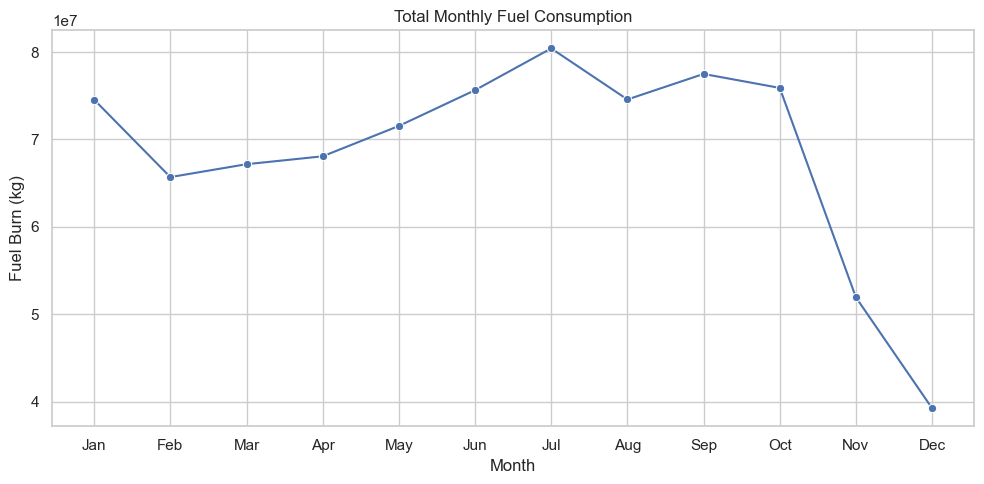

In [3]:
#seasonal variation
df["STDUTC"] = pd.to_datetime(df["STDUTC"])

df["month"] = df["STDUTC"].dt.month
df["month_name"] = df["STDUTC"].dt.strftime("%b")
monthly_flights = (
    df.groupby("month_name")
    .size()
    .reindex(["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"])
)
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")

plt.figure(figsize=(10,5))

sns.lineplot(
    x=monthly_flights.index,
    y=monthly_flights.values,
    marker="o"
)

plt.title("Monthly Flight Volume")
plt.xlabel("Month")
plt.ylabel("Number of Flights")

plt.tight_layout()
plt.show()
monthly_flights
monthly_fuel = (
    df.groupby("month_name")["fuel_kg"]
    .sum()
    .reindex(["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"])
)

plt.figure(figsize=(10,5))

sns.lineplot(
    x=monthly_fuel.index,
    y=monthly_fuel.values,
    marker="o"
)

plt.title("Total Monthly Fuel Consumption")
plt.xlabel("Month")
plt.ylabel("Fuel Burn (kg)")

plt.tight_layout()
plt.show()


## 2. Grouping similar aircraft

### Reasoning

The dataset does not include individual tail numbers, so the best available proxy for “similar airplanes” is the **equipment family** and its observed operating profile.

To group aircraft in a way that is useful for route and fuel analysis, I used the median values of:

- **take-off weight**
- **trip time**
- **ground distance**
- **fuel burn**

Standardizing those variables and checking clustering quality for a few values of **k**.  
With only five equipment families, the data naturally splits into **two broad groups**:

- lighter regional aircraft
- heavier Airbus narrowbodies

However, for business interpretation, **three groups** are more useful because they preserve the distinction between:

- **ATR turboprops**
- **Embraer regional jets**
- **Airbus mainline narrowbodies**

That matches how airlines usually think about route assignment and fleet planning.


In [ ]:
cluster_features = equipment_profile[[
    "tow_median",
    "trip_time_median_min",
    "distance_median_nm",
    "fuel_median_kg"
]]

scaler = StandardScaler()
X = scaler.fit_transform(cluster_features)
OMP_NUM_THREADS = 1

silhouette_table = []
for k in range(2, 5):
    model = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=20)
    labels = model.fit_predict(X)
    silhouette_table.append({"k": k, "silhouette_score": silhouette_score(X, labels)})

pd.DataFrame(silhouette_table)

c:\Users\lcbrs\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\lcbrs\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\lcbrs\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


,k,silhouette_score
0,2,0.62
1,3,0.44
2,4,0.26


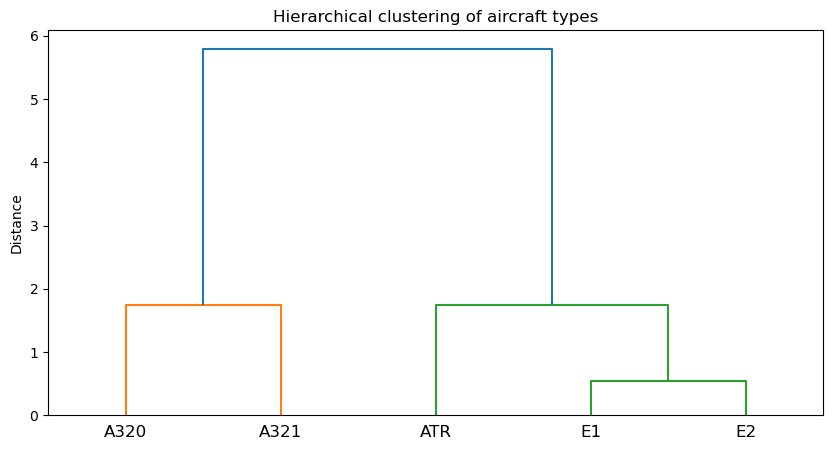

In [8]:
Z = linkage(X, method="ward")

plt.figure(figsize=(10, 5))
dendrogram(Z, labels=cluster_features.index.tolist())
plt.title("Hierarchical clustering of aircraft types")
plt.ylabel("Distance")
plt.show()

In [9]:
raw_clusters = fcluster(Z, 3, criterion="maxclust")
clustered = equipment_profile.copy()
clustered["cluster_id"] = raw_clusters

# manual naming for interpretability after inspecting the profiles
cluster_name_map = {}
for equipment, cid in zip(clustered.index, clustered["cluster_id"]):
    if equipment == "ATR":
        cluster_name_map[cid] = "Regional turboprop"
    elif equipment in ["E1", "E2"]:
        cluster_name_map[cid] = "Regional jet / short-medium haul"
    elif equipment in ["A320", "A321"]:
        cluster_name_map[cid] = "Mainline narrowbody / medium-long haul"

clustered["operational_group"] = clustered["cluster_id"].map(cluster_name_map)
clustered = clustered.sort_values(["cluster_id", "distance_mean_nm"])
clustered

,flights,unique_routes,tow_mean,tow_median,trip_time_mean_min,trip_time_median_min,distance_mean_nm,distance_median_nm,fuel_mean_kg,fuel_median_kg,cluster_id,operational_group
Equipment,,,,,,,,,,,,
A320,100893,294,"66,298.47","66,644.00",123.86,128.00,846.76,889.20,"4,495.91","4,529.00",1,Mainline narrowbody / medium-long haul
A321,13794,96,"79,301.27","80,116.50",165.62,167.00,"1,172.84","1,170.40","7,028.72","7,116.50",1,Mainline narrowbody / medium-long haul
E1,44816,269,"43,961.83","44,428.50",60.66,53.00,354.00,295.60,"2,252.26","1,994.00",2,Regional jet / short-medium haul
E2,50314,260,"52,455.81","52,743.00",78.58,64.00,491.27,382.80,"2,345.78","1,977.00",2,Regional jet / short-medium haul
ATR,78520,220,"20,881.07","21,225.00",62.80,62.00,231.28,231.00,671.55,660.00,3,Regional turboprop


### Why these groups make sense

- **Regional turboprop**: ATR stands alone because it has much lower weight, shorter stage lengths, and much lower fuel burn. It is typically used on shorter regional sectors.
- **Regional jet / short-medium haul**: E1 and E2 are close to each other. They are heavier and faster than ATR, but still operate shorter routes than the Airbus family.
- **Mainline narrowbody / medium-long haul**: A320 and A321 cluster together because they operate the longest trips, at the highest weights, and with the highest fuel burn.

Those aircraft share similar **time, distance, and TOW ranges** and are more likely to be substitutes on similar routes.


In [10]:
group_summary = (
    clustered.groupby("operational_group")[[
        "flights",
        "unique_routes",
        "tow_median",
        "trip_time_median_min",
        "distance_median_nm",
        "fuel_median_kg"
    ]]
    .mean()
    .sort_values("distance_median_nm")
)
group_summary

,flights,unique_routes,tow_median,trip_time_median_min,distance_median_nm,fuel_median_kg
operational_group,,,,,,
Regional turboprop,"78,520.00",220.00,"21,225.00",62.00,231.00,660.00
Regional jet / short-medium haul,"47,565.00",264.50,"48,585.75",58.50,339.20,"1,985.50"
Mainline narrowbody / medium-long haul,"57,343.50",195.00,"73,380.25",147.50,"1,029.80","5,822.75"


## 3. Scatter plots with trend lines

To keep plots readable, I used a sample for the scatter points and compute the trend line from the same sample.


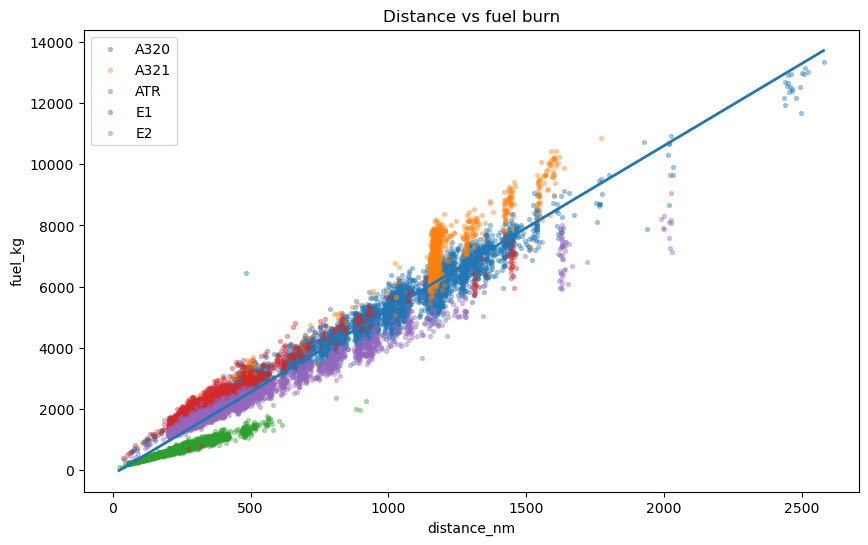

In [11]:
plot_sample = df.sample(n=min(15000, len(df)), random_state=RANDOM_STATE).copy()

def scatter_with_trend(data, x, y, title, by_equipment=False):
    plt.figure(figsize=(10, 6))

    if by_equipment:
        for equipment, g in data.groupby("Equipment"):
            plt.scatter(g[x], g[y], s=8, alpha=0.35, label=equipment)
        plt.legend()
    else:
        plt.scatter(data[x], data[y], s=8, alpha=0.35)

    coef = np.polyfit(data[x], data[y], 1)
    x_line = np.linspace(data[x].min(), data[x].max(), 200)
    y_line = coef[0] * x_line + coef[1]
    plt.plot(x_line, y_line, linewidth=2)

    plt.title(title)
    plt.xlabel(x)
    plt.ylabel(y)
    plt.show()

scatter_with_trend(plot_sample, "distance_nm", "fuel_kg", "Distance vs fuel burn", by_equipment=True)

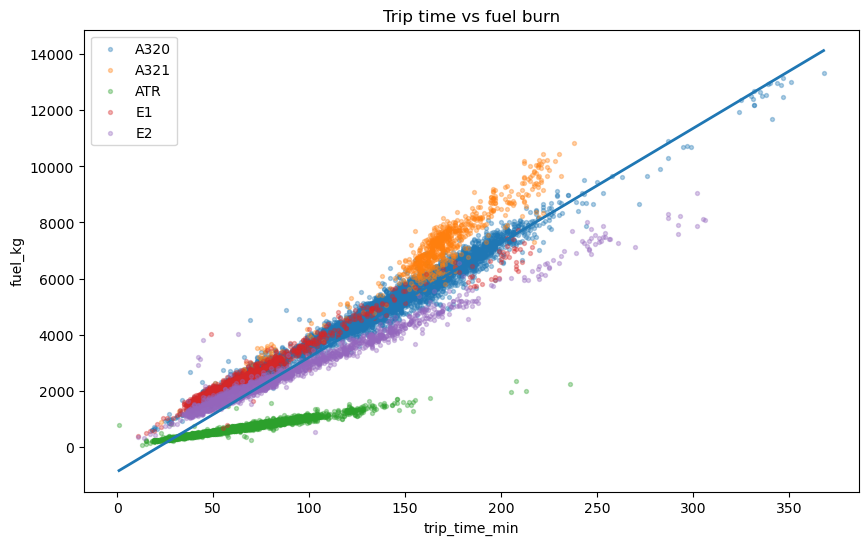

In [12]:
scatter_with_trend(plot_sample, "trip_time_min", "fuel_kg", "Trip time vs fuel burn", by_equipment=True)

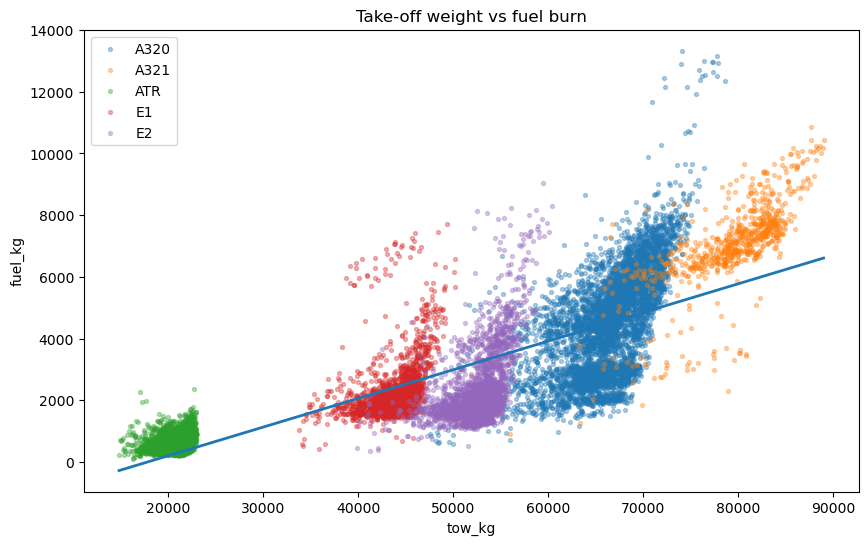

In [13]:
scatter_with_trend(plot_sample, "tow_kg", "fuel_kg", "Take-off weight vs fuel burn", by_equipment=True)

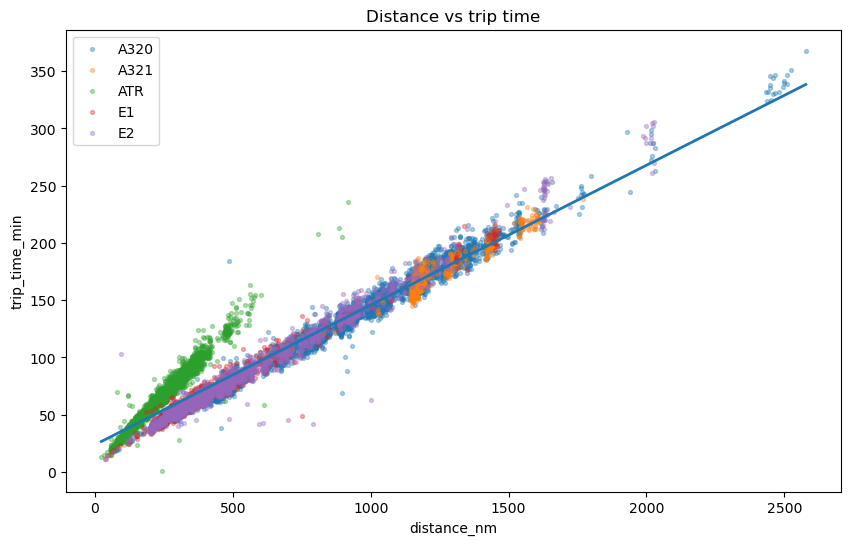

In [14]:
scatter_with_trend(plot_sample, "distance_nm", "trip_time_min", "Distance vs trip time", by_equipment=True)

### First visual takeaways

- **Distance and trip time** should be very strongly related
- **Fuel burn** should rise strongly with both **distance** and **trip time**
- **Take-off weight** should also matter, but likely with more dispersion because route length and aircraft family influence fuel burn at the same time
- The colored scatter plots help show whether the same global trend holds within each aircraft family


## 4. Correlation analysis

Using **Pearson** and **Spearman** correlations on the full dataset, then check how fuel burn behaves within each aircraft family.


In [15]:
pearson_corr = df[numeric_cols].corr(method="pearson")
spearman_corr = df[numeric_cols].corr(method="spearman")

print("Pearson correlation")
display(pearson_corr)

print("\nSpearman correlation")
display(spearman_corr)

Pearson correlation


,fuel_kg,tow_kg,trip_time_min,distance_nm
fuel_kg,1.00,0.83,0.92,0.97
tow_kg,0.83,1.00,0.62,0.74
trip_time_min,0.92,0.62,1.00,0.97
distance_nm,0.97,0.74,0.97,1.00



Spearman correlation


,fuel_kg,tow_kg,trip_time_min,distance_nm
fuel_kg,1.00,0.90,0.83,0.96
tow_kg,0.90,1.00,0.67,0.83
trip_time_min,0.83,0.67,1.00,0.93
distance_nm,0.96,0.83,0.93,1.00


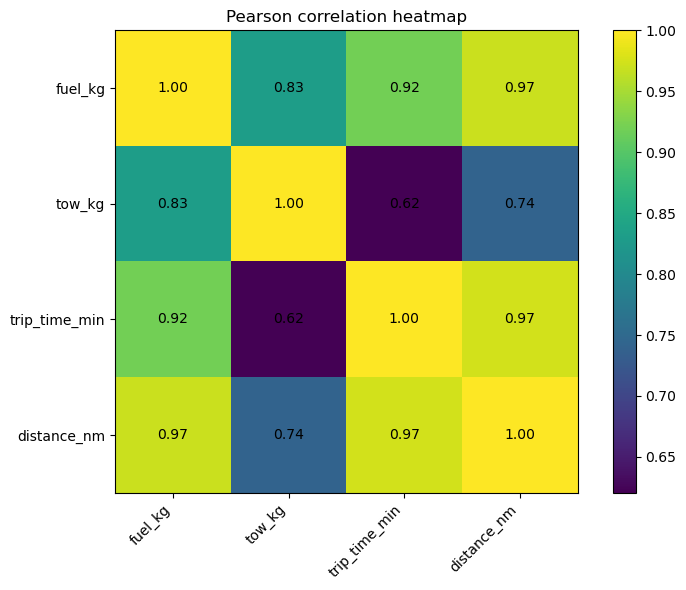

In [16]:
def plot_corr_heatmap(corr_df, title):
    fig, ax = plt.subplots(figsize=(8, 6))
    im = ax.imshow(corr_df.values)
    ax.set_xticks(range(len(corr_df.columns)))
    ax.set_yticks(range(len(corr_df.index)))
    ax.set_xticklabels(corr_df.columns, rotation=45, ha="right")
    ax.set_yticklabels(corr_df.index)
    ax.set_title(title)

    for i in range(corr_df.shape[0]):
        for j in range(corr_df.shape[1]):
            ax.text(j, i, f"{corr_df.iloc[i, j]:.2f}", ha="center", va="center")

    fig.colorbar(im, ax=ax)
    plt.tight_layout()
    plt.show()

plot_corr_heatmap(pearson_corr, "Pearson correlation heatmap")

In [17]:
fuel_corr_by_equipment = []
for equipment, g in df.groupby("Equipment"):
    row = {
        "Equipment": equipment,
        "fuel_vs_tow": g["fuel_kg"].corr(g["tow_kg"]),
        "fuel_vs_trip_time": g["fuel_kg"].corr(g["trip_time_min"]),
        "fuel_vs_distance": g["fuel_kg"].corr(g["distance_nm"]),
    }
    fuel_corr_by_equipment.append(row)

fuel_corr_by_equipment = pd.DataFrame(fuel_corr_by_equipment).sort_values("Equipment")
fuel_corr_by_equipment

,Equipment,fuel_vs_tow,fuel_vs_trip_time,fuel_vs_distance
0,A320,0.64,0.99,0.98
1,A321,0.72,0.96,0.94
2,ATR,0.33,0.98,0.98
3,E1,0.35,0.98,0.98
4,E2,0.51,0.95,0.95


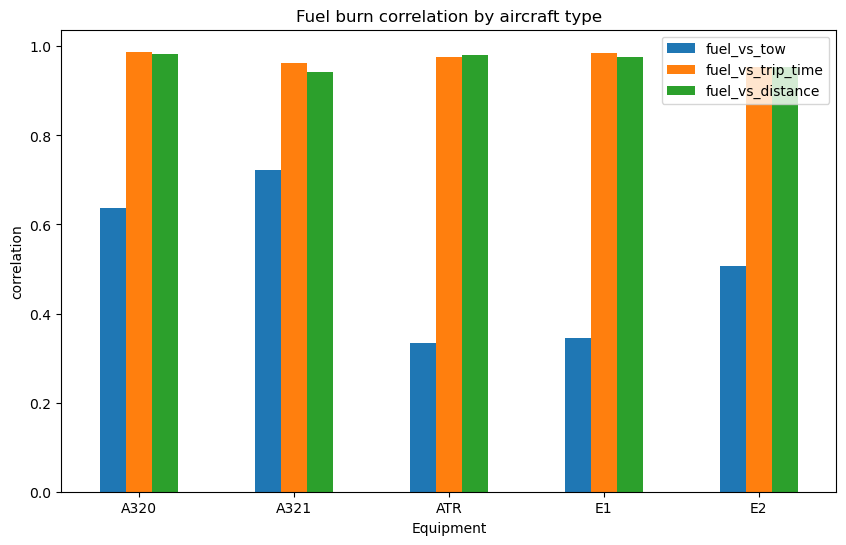

In [18]:
fuel_corr_plot = fuel_corr_by_equipment.set_index("Equipment")

fuel_corr_plot.plot(kind="bar", figsize=(10, 6))
plt.title("Fuel burn correlation by aircraft type")
plt.ylabel("correlation")
plt.xticks(rotation=0)
plt.show()

## 5. Interpretation

### What seems most correlated

On the full dataset, the strongest expected relationships should be:

1. **distance_nm ↔ trip_time_min**
2. **fuel_kg ↔ distance_nm**
3. **fuel_kg ↔ trip_time_min**

**tow_kg** should also correlate with **fuel_kg**, but usually less strongly than distance and time because different aircraft families fly different routes.

### What to watch out for

- **Distance** and **trip time** are probably close substitutes in a model, so using both in the same linear model may create multicollinearity.
- The overall correlation can be inflated by aircraft-family differences. That is why checking correlations **within each equipment type** is important.
- A good next step would be a route-level or equipment-level efficiency metric, such as:
  - fuel burn per nautical mile
  - fuel burn per minute
  - fuel burn per kg of take-off weight


In [19]:
# Optional starting point for a simple efficiency analysis
df["fuel_per_nm"] = df["fuel_kg"] / df["distance_nm"]
df["fuel_per_min"] = df["fuel_kg"] / df["trip_time_min"]

efficiency_summary = (
    df.groupby("Equipment")[["fuel_per_nm", "fuel_per_min"]]
      .median()
      .sort_values("fuel_per_nm")
)

efficiency_summary

,fuel_per_nm,fuel_per_min
Equipment,,
ATR,2.96,10.75
E2,4.98,29.95
A320,5.38,36.48
A321,6.01,42.51
E1,6.68,37.42


## Building Markov Matrix to analyze node connections

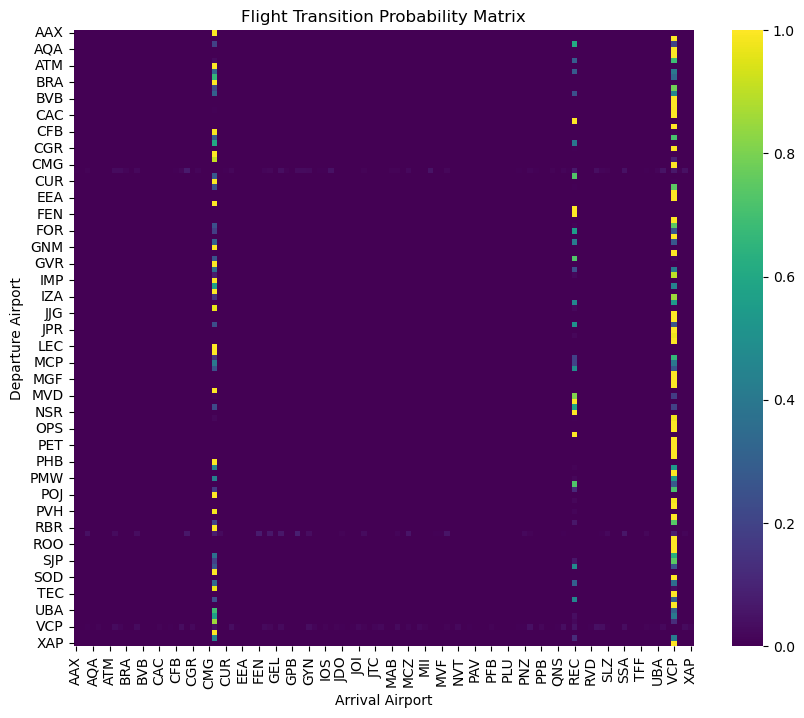

In [3]:
transition_counts = pd.crosstab(
    df["DepartureStation"],
    df["ArrivalStation"]
)
markov_matrix = transition_counts.div(
    transition_counts.sum(axis=1),
    axis=0
)

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))

sns.heatmap(
    markov_matrix,
    cmap="viridis"
)

plt.title("Flight Transition Probability Matrix")
plt.xlabel("Arrival Airport")
plt.ylabel("Departure Airport")

plt.show()


## 6. Implementing the next step: efficiency analysis

It is probably a good ideia to move from raw operational variables to **efficiency metrics**.  
This is useful because two aircraft may burn different total fuel simply because they fly different missions.  
To make the comparison fairer, the code below does three things:

1. Creates normalized efficiency metrics
   - **fuel burn per nautical mile**
   - **fuel burn per minute**
   - **fuel burn per 1,000 kg of take-off weight**

2. Summarizes these metrics by **equipment** and **operational group**

3. Adds a **route-normalized comparison**, so aircraft are compared on routes where more than one equipment type appears

In [20]:
# Build a clean base for efficiency metrics
eff_df = df[
    (df["fuel_kg"] > 0) &
    (df["trip_time_min"] > 0) &
    (df["distance_nm"] > 0) &
    (df["tow_kg"] > 0)
].copy()

eff_df["operational_group"] = eff_df["Equipment"].map(clustered["operational_group"].to_dict())
eff_df["fuel_per_nm"] = eff_df["fuel_kg"] / eff_df["distance_nm"]
eff_df["fuel_per_min"] = eff_df["fuel_kg"] / eff_df["trip_time_min"]
eff_df["fuel_per_1000kg_tow"] = eff_df["fuel_kg"] / (eff_df["tow_kg"] / 1000)

quality_check = pd.DataFrame({
    "metric": ["rows_original", "rows_efficiency_base", "rows_removed"],
    "value": [len(df), len(eff_df), len(df) - len(eff_df)]
})
quality_check

,metric,value
0,rows_original,288337
1,rows_efficiency_base,288332
2,rows_removed,5


In [21]:
efficiency_summary_equipment = (
    eff_df.groupby(["operational_group", "Equipment"])
          .agg(
              flights=("FlightNumber", "count"),
              median_fuel_per_nm=("fuel_per_nm", "median"),
              median_fuel_per_min=("fuel_per_min", "median"),
              median_fuel_per_1000kg_tow=("fuel_per_1000kg_tow", "median"),
              median_distance_nm=("distance_nm", "median"),
              median_trip_time_min=("trip_time_min", "median")
          )
          .sort_values(["operational_group", "median_fuel_per_nm"])
)

efficiency_summary_equipment

flights  median_fuel_per_nm  \
operational_group                      Equipment                                
Mainline narrowbody / medium-long haul A320        100893                5.38   
                                       A321         13794                6.01   
Regional jet / short-medium haul       E2           50309                4.98   
                                       E1           44816                6.68   
Regional turboprop                     ATR          78520                2.96   

                                                  median_fuel_per_min  \
operational_group                      Equipment                        
Mainline narrowbody / medium-long haul A320                     36.48   
                                       A321                     42.51   
Regional jet / short-medium haul       E2                       29.95   
                                       E1                       37.42   
Regional turboprop                     ATR                      10.75   

                                                  median_fuel_per_1000kg_tow  \
operational_group                      Equipment                               
Mainline narrowbody / medium-long haul A320                            69.40   
                                       A321                            89.12   
Regional jet / short-medium haul       E2                              37.89   
                                       E1                              45.66   
Regional turboprop                     ATR                             31.54   

                                                  median_distance_nm  \
operational_group                      Equipment                       
Mainline narrowbody / medium-long haul A320                   889.20   
                                       A321                 1,170.40   
Regional jet / short-medium haul       E2                     382.80   
                                       E1                     295.60   
Regional turboprop                     ATR                    231.00   

                                                  median_trip_time_min  
operational_group                      Equipment                        
Mainline narrowbody / medium-long haul A320                     128.00  
                                       A321                     167.00  
Regional jet / short-medium haul       E2                        64.00  
                                       E1                        53.00  
Regional turboprop                     ATR                       62.00

In [22]:
efficiency_summary_group = (
    eff_df.groupby("operational_group")
          .agg(
              flights=("FlightNumber", "count"),
              median_fuel_per_nm=("fuel_per_nm", "median"),
              median_fuel_per_min=("fuel_per_min", "median"),
              median_fuel_per_1000kg_tow=("fuel_per_1000kg_tow", "median"),
              median_distance_nm=("distance_nm", "median"),
              median_trip_time_min=("trip_time_min", "median")
          )
          .sort_values("median_fuel_per_nm")
)

efficiency_summary_group

,flights,median_fuel_per_nm,median_fuel_per_min,median_fuel_per_1000kg_tow,median_distance_nm,median_trip_time_min
operational_group,,,,,,
Regional turboprop,78520,2.96,10.75,31.54,231.00,62.00
Mainline narrowbody / medium-long haul,114687,5.45,36.78,72.23,917.90,133.00
Regional jet / short-medium haul,95125,5.65,32.91,42.20,345.70,59.00


C:\Users\lcbrs\AppData\Local\Temp\ipykernel_17728\1379801930.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=equipment_order, showfliers=False)
C:\Users\lcbrs\AppData\Local\Temp\ipykernel_17728\1379801930.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=equipment_order, showfliers=False)
C:\Users\lcbrs\AppData\Local\Temp\ipykernel_17728\1379801930.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=equipment_order, showfliers=False)


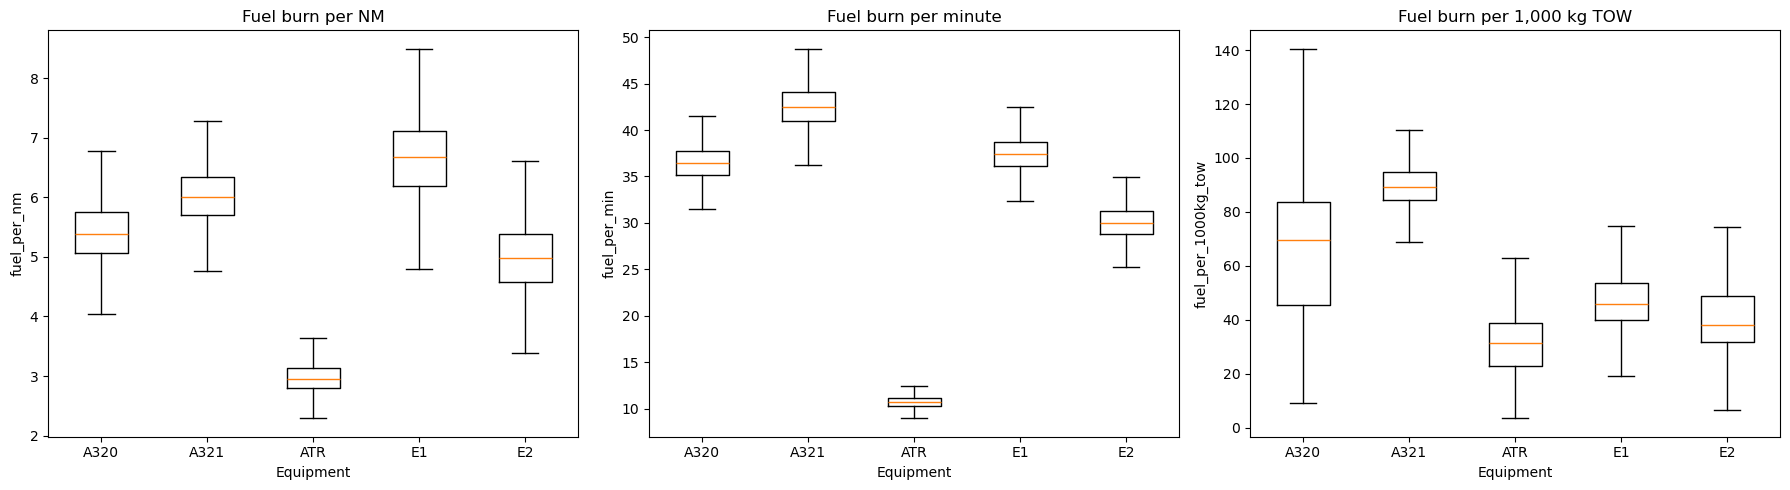

In [23]:
# Visual comparison of efficiency metrics by equipment
equipment_order = sorted(eff_df["Equipment"].unique())
metrics_to_plot = [
    ("fuel_per_nm", "Fuel burn per NM"),
    ("fuel_per_min", "Fuel burn per minute"),
    ("fuel_per_1000kg_tow", "Fuel burn per 1,000 kg TOW")
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (metric, title) in zip(axes, metrics_to_plot):
    data = [eff_df.loc[eff_df["Equipment"] == eq, metric].dropna() for eq in equipment_order]
    ax.boxplot(data, labels=equipment_order, showfliers=False)
    ax.set_title(title)
    ax.set_xlabel("Equipment")
    ax.set_ylabel(metric)

plt.tight_layout()
plt.show()

### Route-normalized comparison

A raw comparison can still be biased because some aircraft systematically fly longer or heavier routes.  
To reduce that effect, the next step compares equipment types only on **shared routes**.

Rules used below:
- keep only route-equipment combinations with at least **20 flights**
- keep only routes served by at least **2 equipment types**
- compute each equipment's **median fuel per NM** on that route
- compare it against the **route median**, creating an index:
  - **below 1.00** = better than the route median
  - **above 1.00** = worse than the route median

In [24]:
pair_counts = (
    eff_df.groupby(["route", "Equipment"])
          .size()
          .reset_index(name="flights")
)

valid_pairs = pair_counts[pair_counts["flights"] >= 20].copy()
valid_routes = (
    valid_pairs.groupby("route")["Equipment"]
               .nunique()
)
valid_routes = valid_routes[valid_routes >= 2].index

route_sample = eff_df.merge(
    valid_pairs[["route", "Equipment"]],
    on=["route", "Equipment"],
    how="inner"
)
route_sample = route_sample[route_sample["route"].isin(valid_routes)].copy()

route_equipment_eff = (
    route_sample.groupby(["route", "Equipment", "operational_group"])
                .agg(
                    flights=("route", "size"),
                    median_fuel_per_nm=("fuel_per_nm", "median"),
                    median_fuel_per_min=("fuel_per_min", "median"),
                    median_distance_nm=("distance_nm", "median"),
                    median_trip_time_min=("trip_time_min", "median")
                )
                .reset_index()
)

route_equipment_eff["route_median_fuel_per_nm"] = (
    route_equipment_eff.groupby("route")["median_fuel_per_nm"]
                       .transform("median")
)
route_equipment_eff["fuel_per_nm_index_vs_route"] = (
    route_equipment_eff["median_fuel_per_nm"] /
    route_equipment_eff["route_median_fuel_per_nm"]
)

route_equipment_eff.head()

,route,Equipment,operational_group,flights,median_fuel_per_nm,median_fuel_per_min,median_distance_nm,median_trip_time_min,route_median_fuel_per_nm,fuel_per_nm_index_vs_route
0,AJU-CNF,A320,Mainline narrowbody / medium-long haul,294,5.51,36.43,681.20,104.00,5.08,1.08
1,AJU-CNF,E2,Regional jet / short-medium haul,209,4.65,29.75,683.60,107.00,5.08,0.92
2,AJU-REC,ATR,Regional turboprop,1535,2.95,10.61,236.00,66.00,5.48,0.54
3,AJU-REC,E1,Regional jet / short-medium haul,26,6.96,37.70,233.40,43.50,5.48,1.27
4,AJU-REC,E2,Regional jet / short-medium haul,57,5.48,29.36,235.10,44.00,5.48,1.00


In [25]:
route_normalized_summary = (
    route_equipment_eff.groupby(["operational_group", "Equipment"])
                       .apply(
                           lambda g: pd.Series({
                               "shared_routes": g["route"].nunique(),
                               "total_flights_in_shared_routes": g["flights"].sum(),
                               "weighted_fuel_per_nm_index": np.average(
                                   g["fuel_per_nm_index_vs_route"],
                                   weights=g["flights"]
                               ),
                               "weighted_fuel_per_min": np.average(
                                   g["median_fuel_per_min"],
                                   weights=g["flights"]
                               )
                           }),
                           include_groups=False
                       )
                       .reset_index()
                       .sort_values("weighted_fuel_per_nm_index")
)

route_normalized_summary

,operational_group,Equipment,shared_routes,total_flights_in_shared_routes,weighted_fuel_per_nm_index,weighted_fuel_per_min
4,Regional turboprop,ATR,63.00,"44,354.00",0.54,10.75
3,Regional jet / short-medium haul,E2,152.00,"48,796.00",0.88,30.09
0,Mainline narrowbody / medium-long haul,A320,156.00,"85,444.00",1.03,36.60
2,Regional jet / short-medium haul,E1,134.00,"43,851.00",1.12,37.37
1,Mainline narrowbody / medium-long haul,A321,30.00,"13,460.00",1.13,42.69


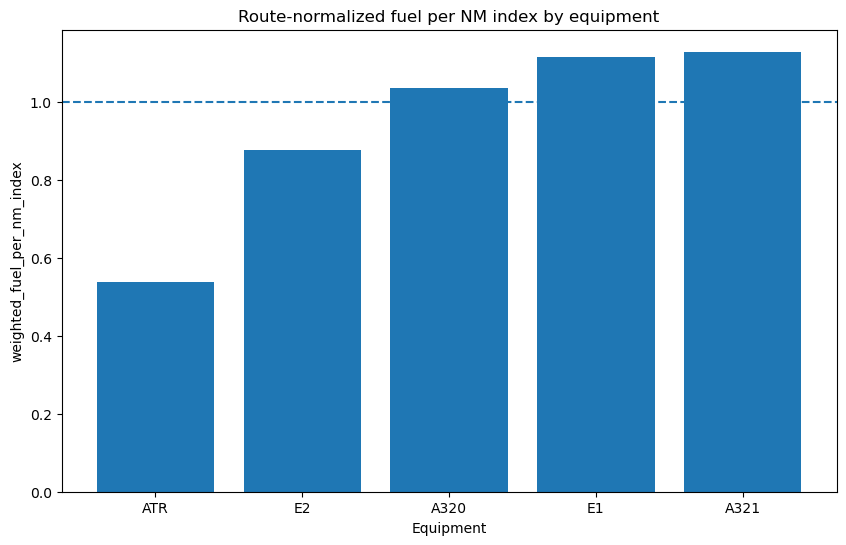

In [26]:
plt.figure(figsize=(10, 6))
plt.bar(
    route_normalized_summary["Equipment"],
    route_normalized_summary["weighted_fuel_per_nm_index"]
)
plt.axhline(1.0, linestyle="--")
plt.title("Route-normalized fuel per NM index by equipment")
plt.ylabel("weighted_fuel_per_nm_index")
plt.xlabel("Equipment")
plt.show()

In [27]:
# Look at the busiest shared routes to inspect substitution potential
top_shared_routes = (
    route_equipment_eff.groupby("route")["flights"]
                       .sum()
                       .sort_values(ascending=False)
                       .head(12)
                       .index
)

top_shared_route_table = (
    route_equipment_eff[route_equipment_eff["route"].isin(top_shared_routes)]
    .pivot(index="route", columns="Equipment", values="median_fuel_per_nm")
    .sort_index()
)

top_shared_route_table

Equipment,A320,A321,ATR,E1,E2
route,,,,,
CGH-CNF,6.13,NaN,NaN,6.28,5.11
CNF-CGH,6.35,NaN,NaN,6.59,5.22
CNF-REC,4.91,NaN,NaN,NaN,4.05
CNF-VCP,6.60,NaN,2.86,6.73,5.37
CWB-VCP,7.06,NaN,2.90,7.31,6.00
GRU-REC,4.88,5.66,NaN,NaN,NaN
REC-CNF,5.36,NaN,NaN,NaN,4.53
REC-GRU,5.49,6.31,NaN,NaN,4.46
REC-VCP,5.48,6.35,NaN,NaN,4.54


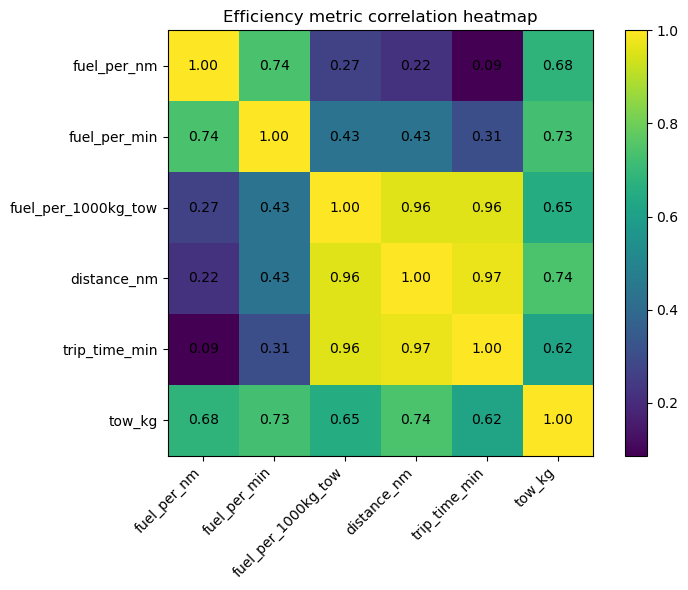

In [28]:
efficiency_corr = eff_df[[
    "fuel_per_nm",
    "fuel_per_min",
    "fuel_per_1000kg_tow",
    "distance_nm",
    "trip_time_min",
    "tow_kg"
]].corr()

plot_corr_heatmap(efficiency_corr, "Efficiency metric correlation heatmap")

## 7. After the efficiency step

This efficiency analysis is already strong enough to support exploratory conclusions.  
The next step is a **controlled comparison** that separates mission profile from aircraft effect.

The section below implements that logic in two ways:

1. a model of **fuel burn** using operational variables and equipment type
2. a **route-controlled model** of fuel per NM, comparing aircraft only where they overlap


## 8. Controlled analysis

As stated above, the exploratory analysis already shows strong patterns, but raw comparisons can still be misleading because different aircraft fly different missions.

To move one step further, this section estimates simple controlled models.

### Why separate models are useful here

**distance_nm** and **trip_time_min** are extremely close operational proxies in this dataset.  
Their VIF values are high, about **45.3** for distance and **33.2** for trip time, while **tow_kg** is much lower at about **3.9**.

Because of that, fitting separate models instead of forcing distance and time into the same specification is more appealing.

### Models estimated

1. **Fuel burn model with distance**
   - `fuel_kg ~ distance_nm + C(Equipment)`

2. **Fuel burn model with trip time**
   - `fuel_kg ~ trip_time_min + C(Equipment)`

3. **Fuel burn model with distance, TOW and equipment**
   - `fuel_kg ~ distance_nm + tow_kg + C(Equipment)`

4. **Route-controlled efficiency model**
   - `median_fuel_per_nm ~ C(Equipment) + C(route)`

The route-controlled model uses only shared routes with enough observations and weights each route-equipment pair by flight count.


In [29]:
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Check multicollinearity on a manageable sample
vif_sample = df[["distance_nm", "trip_time_min", "tow_kg"]].sample(
    n=min(50000, len(df)),
    random_state=RANDOM_STATE
).copy()

X_vif = sm.add_constant(vif_sample)
vif_table = pd.DataFrame({
    "variable": X_vif.columns,
    "VIF": [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
})

vif_table


,variable,VIF
0,const,30.16
1,distance_nm,47.34
2,trip_time_min,34.68
3,tow_kg,3.98


In [30]:
# Controlled fuel burn models
model_distance = smf.ols(
    "fuel_kg ~ distance_nm + C(Equipment)",
    data=eff_df
).fit()

model_time = smf.ols(
    "fuel_kg ~ trip_time_min + C(Equipment)",
    data=eff_df
).fit()

model_distance_tow = smf.ols(
    "fuel_kg ~ distance_nm + tow_kg + C(Equipment)",
    data=eff_df
).fit()

model_comparison = pd.DataFrame({
    "model": [
        "fuel_kg ~ distance + equipment",
        "fuel_kg ~ trip time + equipment",
        "fuel_kg ~ distance + TOW + equipment"
    ],
    "R_squared": [
        model_distance.rsquared,
        model_time.rsquared,
        model_distance_tow.rsquared
    ],
    "Adj_R_squared": [
        model_distance.rsquared_adj,
        model_time.rsquared_adj,
        model_distance_tow.rsquared_adj
    ],
    "observations": [
        int(model_distance.nobs),
        int(model_time.nobs),
        int(model_distance_tow.nobs)
    ]
})

model_comparison


,model,R_squared,Adj_R_squared,observations
0,fuel_kg ~ distance + equipment,0.98,0.98,288332
1,fuel_kg ~ trip time + equipment,0.97,0.97,288332
2,fuel_kg ~ distance + TOW + equipment,0.99,0.99,288332


In [31]:
# Equipment coefficients from the controlled fuel burn models
equipment_coef_distance = (
    model_distance.params.filter(like="C(Equipment)")
    .rename(lambda x: x.replace("C(Equipment)[T.", "").replace("]", ""))
    .rename("coef_distance_model")
)

equipment_coef_time = (
    model_time.params.filter(like="C(Equipment)")
    .rename(lambda x: x.replace("C(Equipment)[T.", "").replace("]", ""))
    .rename("coef_time_model")
)

equipment_coef_distance_tow = (
    model_distance_tow.params.filter(like="C(Equipment)")
    .rename(lambda x: x.replace("C(Equipment)[T.", "").replace("]", ""))
    .rename("coef_distance_tow_model")
)

controlled_equipment_effect = pd.concat(
    [equipment_coef_distance, equipment_coef_time, equipment_coef_distance_tow],
    axis=1
).reset_index().rename(columns={"index": "Equipment"})

controlled_equipment_effect


,Equipment,coef_distance_model,coef_time_model,coef_distance_tow_model
0,A321,"1,059.60","1,224.17",354.73
1,ATR,"-1,043.58","-1,910.64","1,599.78"
2,E1,-17.35,-262.90,"1,216.84"
3,E2,-541.55,-728.60,205.95


### Route-controlled efficiency model

Now for the one million dollar question:

**When different aircraft types fly the same route, which one tends to burn less fuel per nautical mile?**

To keep the comparison fair, the model:
- uses only **shared routes**
- keeps only route-equipment pairs with at least **20 flights**
- aggregates at the **route-equipment** level using medians
- weights the regression by flight count

The baseline category is **A320**, so each coefficient below should be read as the difference relative to A320 on the same route.


In [32]:
# Route-controlled model on shared routes
route_model = smf.wls(
    "median_fuel_per_nm ~ C(Equipment) + C(route)",
    data=route_equipment_eff,
    weights=route_equipment_eff["flights"]
).fit()

route_equipment_coef = route_model.params.filter(like="C(Equipment)")
route_equipment_ci = route_model.conf_int().loc[route_equipment_coef.index]

route_controlled_effect = pd.DataFrame({
    "Equipment": route_equipment_coef.index.str.replace("C(Equipment)[T.", "", regex=False).str.replace("]", "", regex=False),
    "coef_vs_A320": route_equipment_coef.values,
    "ci_low": route_equipment_ci[0].values,
    "ci_high": route_equipment_ci[1].values
}).sort_values("coef_vs_A320")

route_controlled_effect


,Equipment,coef_vs_A320,ci_low,ci_high
1,ATR,-3.58,-3.65,-3.52
3,E2,-1.01,-1.04,-0.97
2,E1,0.22,0.18,0.26
0,A321,0.81,0.75,0.88


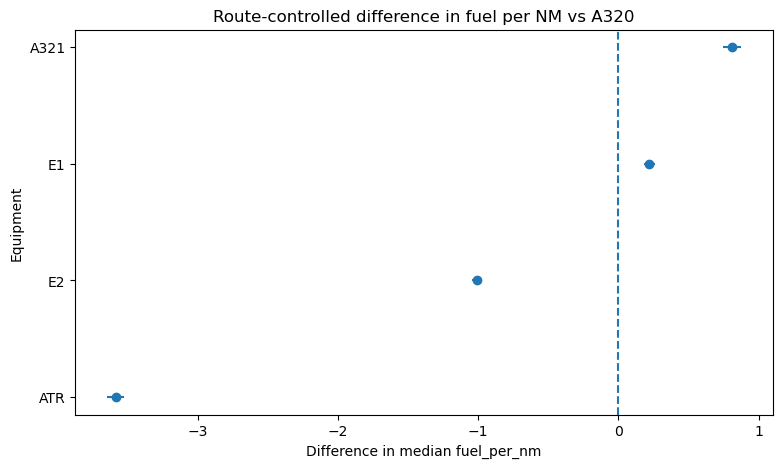

In [33]:
plt.figure(figsize=(9, 5))

plt.errorbar(
    route_controlled_effect["coef_vs_A320"],
    route_controlled_effect["Equipment"],
    xerr=[
        route_controlled_effect["coef_vs_A320"] - route_controlled_effect["ci_low"],
        route_controlled_effect["ci_high"] - route_controlled_effect["coef_vs_A320"]
    ],
    fmt="o"
)
plt.axvline(0, linestyle="--")
plt.title("Route-controlled difference in fuel per NM vs A320")
plt.xlabel("Difference in median fuel_per_nm")
plt.ylabel("Equipment")
plt.show()


## 9. Conclusions written from the current dataset

### Main conclusions

1. **The fleet splits naturally into operational families**  
   ATR behaves like a regional turboprop, E1 and E2 behave like regional jets, and A320 and A321 behave like Airbus narrowbodies.  
   This is visible in take-off weight, trip time, distance, and fuel burn.

2. **Distance and trip time are the main drivers of fuel burn**  
   The controlled models confirm the earlier EDA.  
   A model with **distance and equipment** explains about **0.982** of the variation in fuel burn.  
   A model with **trip time and equipment** explains about **0.969**.  
   Adding **TOW** on top of distance and equipment increases explanatory power to about **0.988**.

3. **Distance and trip time should be handled carefully together**  
   Their VIF values are high, which means they carry overlapping information.  
   For that reason, separate models or more careful specification choices are preferable.

4. **Aircraft type still matters after controlling for mission profile**  
   The route-controlled model, which compares aircraft only on shared routes, still finds systematic differences by equipment type.  
   Its R-squared is about **0.995**, largely because route fixed effects capture a major part of mission structure.

5. **Relative to A320 on the same route, the route-controlled efficiency pattern is:**  
- **ATR**: about **3.58 kg/NM lower** than A320 on the same route
- **E2**: about **1.01 kg/NM lower** than A320 on the same route
- **E1**: about **0.22 kg/NM higher** than A320 on the same route
- **A321**: about **0.81 kg/NM higher** than A320 on the same route

### Practical interpretation

At the exploratory level, the analysis is already good enough to say that:
- mission profile explains most of the fuel burn variation
- aircraft family still adds information after controlling for mission profile
- normalized comparisons, especially **fuel per NM on shared routes**, are more reliable than raw fuel comparisons

### What should not be claimed yet

The notebook does **not** prove that one aircraft is universally better in all contexts. Expecially as it does **not** isolate every operational driver, such as payload, seating configuration, airport constraints (this one is pretty big, Santos-Dumont and Congonhas are great examples), weather, taxi time, altitude profile, or seasonality.
